In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("/content/sample_data/Indian Liver Patient Dataset (ILPD).csv")

print("Dataset Preview:")
print(df.head())

Dataset Preview:
   Age  Gender    TB   DB  Alkphos  Sgpt  Sopt   TP  ALB  A/G Ratio  Selector
0   65  Female   0.7  0.1      187    16    18  6.8  3.3       0.90         1
1   62    Male  10.9  5.5      699    64   100  7.5  3.2       0.74         1
2   62    Male   7.3  4.1      490    60    68  7.0  3.3       0.89         1
3   58    Male   1.0  0.4      182    14    20  6.8  3.4       1.00         1
4   72    Male   3.9  2.0      195    27    59  7.3  2.4       0.40         1


In [4]:
print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


Dataset Shape: (583, 11)

Missing Values:
Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sopt         0
TP           0
ALB          0
A/G Ratio    4
Selector     0
dtype: int64

Statistical Summary:
              Age          TB          DB      Alkphos         Sgpt  \
count  583.000000  583.000000  583.000000   583.000000   583.000000   
mean    44.746141    3.298799    1.486106   290.576329    80.713551   
std     16.189833    6.209522    2.808498   242.937989   182.620356   
min      4.000000    0.400000    0.100000    63.000000    10.000000   
25%     33.000000    0.800000    0.200000   175.500000    23.000000   
50%     45.000000    1.000000    0.300000   208.000000    35.000000   
75%     58.000000    2.600000    1.300000   298.000000    60.500000   
max     90.000000   75.000000   19.700000  2110.000000  2000.000000   

              Sopt          TP         ALB   A/G Ratio    Selector  
count   583.000000  583.000000  583.000000  579.

In [5]:
print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


Dataset Shape: (583, 11)

Missing Values:
Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sopt         0
TP           0
ALB          0
A/G Ratio    4
Selector     0
dtype: int64

Statistical Summary:
              Age          TB          DB      Alkphos         Sgpt  \
count  583.000000  583.000000  583.000000   583.000000   583.000000   
mean    44.746141    3.298799    1.486106   290.576329    80.713551   
std     16.189833    6.209522    2.808498   242.937989   182.620356   
min      4.000000    0.400000    0.100000    63.000000    10.000000   
25%     33.000000    0.800000    0.200000   175.500000    23.000000   
50%     45.000000    1.000000    0.300000   208.000000    35.000000   
75%     58.000000    2.600000    1.300000   298.000000    60.500000   
max     90.000000   75.000000   19.700000  2110.000000  2000.000000   

              Sopt          TP         ALB   A/G Ratio    Selector  
count   583.000000  583.000000  583.000000  579.

In [8]:
# Fill missing numeric values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode Gender (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Convert target column
# ILPD: 1 = Liver Patient, 2 = Non-Liver Patient
df['Selector'] = df['Selector'].replace({1:1, 2:0})

print("\nCleaned Dataset:")
print(df.head())


Cleaned Dataset:
   Age  Gender    TB   DB  Alkphos  Sgpt  Sopt   TP  ALB  A/G Ratio  Selector
0   65       0   0.7  0.1      187    16    18  6.8  3.3       0.90         1
1   62       1  10.9  5.5      699    64   100  7.5  3.2       0.74         1
2   62       1   7.3  4.1      490    60    68  7.0  3.3       0.89         1
3   58       1   1.0  0.4      182    14    20  6.8  3.4       1.00         1
4   72       1   3.9  2.0      195    27    59  7.3  2.4       0.40         1


In [9]:
X = df.drop('Selector', axis=1)
y = df['Selector']

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [16]:
model = SVC(kernel='linear', class_weight='balanced')

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [17]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nSample Predictions:")
print(results.head(10))


Sample Predictions:
   Actual  Predicted
0       0          0
1       1          1
2       1          1
3       1          0
4       1          1
5       1          0
6       0          0
7       0          0
8       0          0
9       1          1


In [18]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.5811965811965812

Confusion Matrix:
[[29  1]
 [48 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.97      0.54        30
           1       0.97      0.45      0.61        87

    accuracy                           0.58       117
   macro avg       0.68      0.71      0.58       117
weighted avg       0.82      0.58      0.60       117



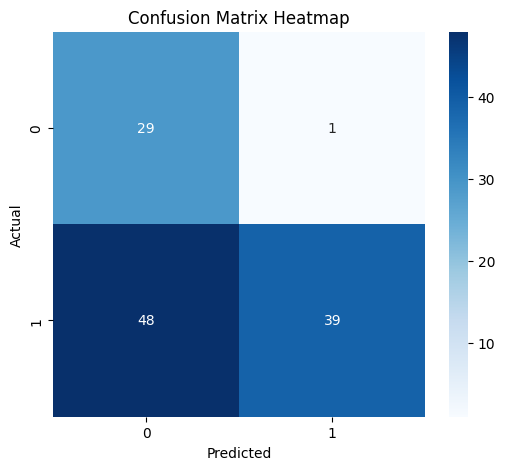

In [19]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()